# Verifying the narrow/broad split with WaveMAP

The narrow/broad label is defined by **one number** — waveform trough-to-peak, split at its GMM
antimode. **WaveMAP** clusters neurons on their **full waveform shape** (UMAP graph → Louvain),
data-driven, no threshold. The question here:

> do WaveMAP's clusters **largely recover the two antimode classes** we already have?

If the richer, unsupervised method rediscovers the same split, the simple 1-D width test is
capturing the real structure. (Unlike the ACG line, this is *not* independent evidence — it's
the same waveform data, full shape vs a single width number. It tests whether one number suffices.)

**Flow** — load waveforms → antimode narrow/broad (computed here) → align/normalize → WaveMAP
cluster → overlay the antimode labels on the embedding and score how well the clusters recover them.
Runs on **000673**, one region pooled across sessions (`SELECT_AREAS`).

## Section 0 — Setup, config

In [1]:
# [0.1] imports, seeds, config
import sys, os, random, warnings, time, json
from pathlib import Path
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt

PROJECT = Path.cwd()                        # run this notebook from E:\SBCAT\celltyping
if str(PROJECT) not in sys.path:
    sys.path.insert(0, str(PROJECT))

from celltyping.features import build_unit_features
from celltyping.classify import assign_narrow_broad          # waveform GMM, computed locally
from celltyping.wavemap import preprocess_waveforms, run_wavemap
from celltyping import viz

RS = 42
os.environ['PYTHONHASHSEED'] = str(RS)
random.seed(RS); np.random.seed(RS)
plt.rcParams['figure.dpi'] = 100

# ---- CONFIG ----
DATASET   = '000673'                        # only 000673 has stored waveforms
DATA_ROOT = PROJECT.parent / 'data' / DATASET
FS_HZ     = 100_000.0                        # OSort convention (256 samples = 2.56 ms)
SELECT_AREAS = ['hippocampus','amygdala']              # region pool for THIS run (pool L+R of a region)
PRE_MS, POST_MS = 0.3, 1.7                   # trough at 0.3 ms; ~2.0 ms window (protocol)
N_NEIGHBORS = 15                             # UMAP graph neighborhood (protocol default)
RESOLUTION  = 2.0                            # Louvain resolution; higher -> FEWER clusters
NB = {'narrow': '#d62728', 'broad': '#1f77b4'}   # narrow=putative IN (red), broad=putative PY (blue)
print(f'{DATASET} | region pool = {SELECT_AREAS} | seed = {RS}')

000673 | region pool = ['hippocampus', 'amygdala'] | seed = 42


In [2]:
# [0.2] all session files (units pooled across sessions within the region)
files = sorted(DATA_ROOT.glob('sub-*/*.nwb'))
assert files, f'no NWB files under {DATA_ROOT}'
print(f'{len(files)} session files under {DATA_ROOT}')

44 session files under e:\SBCAT\data\000673


## Section 1 — Load waveforms + antimode narrow/broad (the label under test)

In [3]:
# [1.1] load polarity-normalized (trough-down) mean waveforms + features for the region pool
t0 = time.time()
df, wfs = build_unit_features(files, fs_hz=FS_HZ, areas=SELECT_AREAS,
                              return_waveforms=True, verbose=True)   # waveform_kind='normalized'
df = df.reset_index(drop=True)
assert len(df) > 0, f'no units in {SELECT_AREAS}'
print(f'\n{len(df)} units from {SELECT_AREAS} in {time.time()-t0:.0f}s '
      f'| subjects={df.subject.nunique()} sessions={df.session_id.nunique()}')

  sub-1_ses-1_ecephys+image: 22/46 units (22 valid waveforms), wf_col=waveforms
  sub-1_ses-2_ecephys+image: 26/41 units (26 valid waveforms), wf_col=waveforms
  sub-10_ses-1_ecephys+image: 23/36 units (23 valid waveforms), wf_col=waveforms
  sub-11_ses-1_ecephys+image: 15/36 units (15 valid waveforms), wf_col=waveforms
  sub-12_ses-1_ecephys+image: 15/24 units (15 valid waveforms), wf_col=waveforms
  sub-12_ses-2_ecephys+image: 6/12 units (6 valid waveforms), wf_col=waveforms
  sub-13_ses-1_ecephys+image: 3/27 units (3 valid waveforms), wf_col=waveforms
  sub-14_ses-1_ecephys+image: 4/13 units (4 valid waveforms), wf_col=waveforms
  sub-15_ses-1_ecephys+image: 22/41 units (22 valid waveforms), wf_col=waveforms
  sub-16_ses-1_ecephys+image: 30/63 units (30 valid waveforms), wf_col=waveforms
  sub-17_ses-1_ecephys+image: 45/80 units (45 valid waveforms), wf_col=waveforms
  sub-18_ses-1_ecephys+image: 27/27 units (27 valid waveforms), wf_col=waveforms
  sub-19_ses-1_ecephys+image: 45/95 

antimode split at 0.426 ms  (narrow=putative IN, broad=putative PY)
wf_group
broad     714
narrow    142


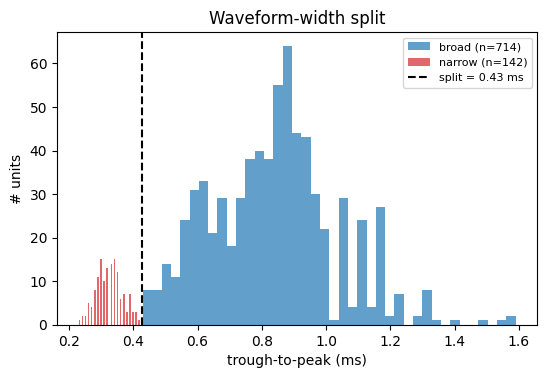

In [4]:
# [1.2] waveform GMM narrow/broad split (antimode of trough-to-peak) -- the label we verify
grp, SPLIT_MS = assign_narrow_broad(df, method='antimode')
df['wf_group'] = grp
print(f'antimode split at {SPLIT_MS:.3f} ms  (narrow=putative IN, broad=putative PY)')
print(df.wf_group.value_counts().to_string())
fig, ax = plt.subplots(figsize=(6.2, 3.8))
viz.plot_waveform_split(df, split_ms=SPLIT_MS, ax=ax)
plt.show()

## Section 2 — Align + normalize (WaveMAP input, protocol steps 1-10)

Trough-align, crop a common ~2.0 ms window, mean-subtract, and divide by max |amplitude| so
WaveMAP clusters on **shape**, not amplitude or polarity.

856/856 units have a usable waveform -> X (856, 200)


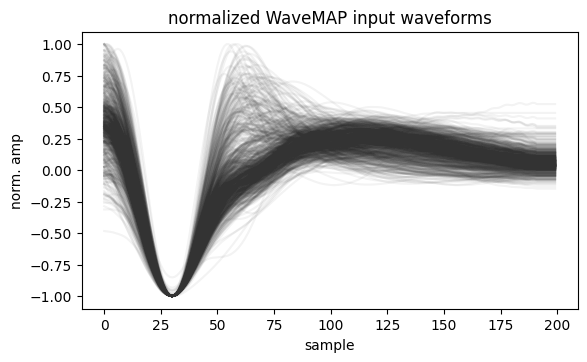

In [5]:
# [2.1] preprocess to the WaveMAP input matrix X (rows aligned to `work`)
X, valid = preprocess_waveforms(wfs, fs_hz=FS_HZ, pre_ms=PRE_MS, post_ms=POST_MS)
work = df.loc[valid].reset_index(drop=True)
print(f'{valid.sum()}/{len(wfs)} units have a usable waveform -> X {X.shape}')
fig, ax = plt.subplots(figsize=(6.4, 3.6))
for w in X:
    ax.plot(w, color='#333', alpha=0.06)
ax.set_title('normalized WaveMAP input waveforms'); ax.set_xlabel('sample'); ax.set_ylabel('norm. amp')
plt.show()

## Section 3 — Run WaveMAP (UMAP graph → Louvain)

One call. If you get too many/few clusters, raise/lower `RESOLUTION` in `[0.1]` (higher → fewer).

In [6]:
# [3.1] WaveMAP: data-driven waveform clusters
wm = run_wavemap(X, n_neighbors=N_NEIGHBORS, resolution=RESOLUTION, random_state=RS)
work['wavemap_cluster'] = wm['labels']
work['umap_x'], work['umap_y'] = wm['embedding'][:, 0], wm['embedding'][:, 1]
sizes = np.bincount(wm['labels']).tolist()
print(f"{X.shape[0]} units -> {len(sizes)} WaveMAP clusters (sizes {sizes})")

856 units -> 21 WaveMAP clusters (sizes [58, 53, 55, 37, 34, 41, 28, 25, 43, 27, 39, 22, 42, 66, 36, 46, 14, 69, 37, 36, 48])


## Section 4 — Do the WaveMAP clusters find the two classes?

Same UMAP embedding, colored two ways: **left** by the antimode narrow/broad label (what we want
to recover), **right** by the data-driven WaveMAP cluster. If the two panels look alike, WaveMAP
rediscovered the width split on its own.

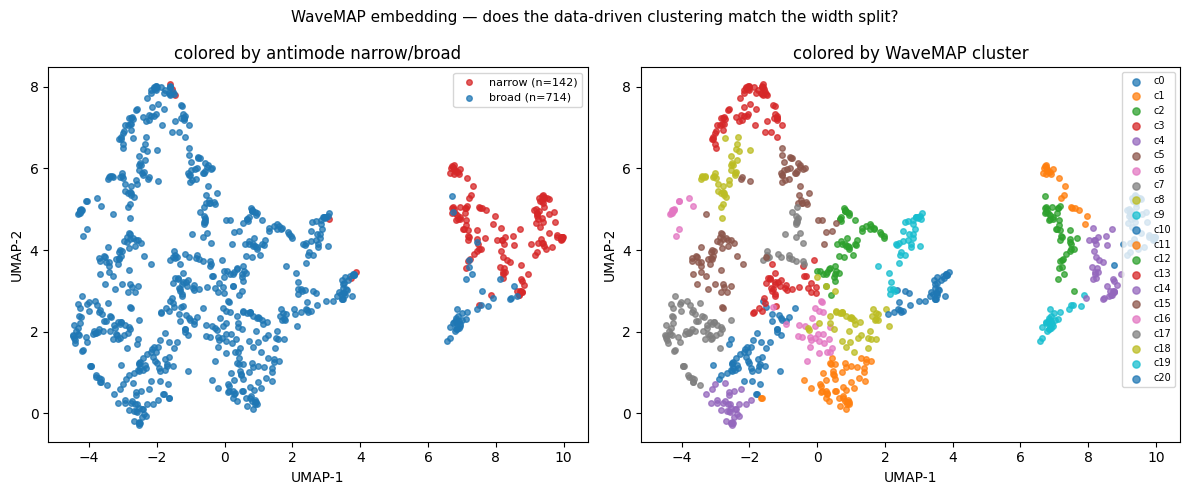

In [7]:
# [4.1] WaveMAP embedding colored by antimode label vs by data-driven cluster
emb = wm['embedding']
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for g, c in NB.items():
    m = (work.wf_group == g).to_numpy()
    axes[0].scatter(emb[m, 0], emb[m, 1], s=16, alpha=0.75, color=c, label=f'{g} (n={int(m.sum())})')
axes[0].set_title('colored by antimode narrow/broad'); axes[0].legend(fontsize=8)
for cl in np.unique(work.wavemap_cluster):
    m = (work.wavemap_cluster == cl).to_numpy()
    axes[1].scatter(emb[m, 0], emb[m, 1], s=16, alpha=0.75, label=f'c{cl}')
axes[1].set_title('colored by WaveMAP cluster'); axes[1].legend(fontsize=7, markerscale=1.3)
for ax in axes: ax.set_xlabel('UMAP-1'); ax.set_ylabel('UMAP-2')
fig.suptitle('WaveMAP embedding — does the data-driven clustering match the width split?', fontsize=11)
fig.tight_layout(); plt.show()

## Section 5 — Agreement (how well the clusters recover the split)

WaveMAP cluster × antimode class:
wf_group         broad  narrow
wavemap_cluster               
0                   58       0
1                   53       0
2                   55       0
3                   37       0
4                   34       0
5                   41       0
6                   28       0
7                   25       0
8                   43       0
9                   25       2
10                  37       2
11                   0      22
12                   8      34
13                  63       3
14                   6      30
15                  46       0
16                  14       0
17                  69       0
18                  37       0
19                  35       1
20                   0      48

clusters mapping to narrow: 4 | to broad: 17
purity (collapse clusters -> majority class): 0.97
ARI = 0.03   NMI = 0.21


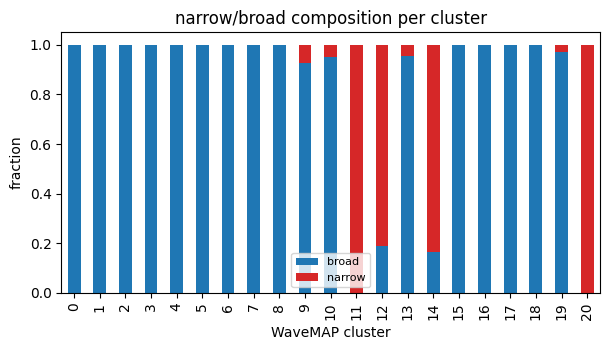

In [8]:
# [5.1] cluster x narrow/broad composition + recovery metrics
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
ab = work.wf_group.isin(['narrow', 'broad'])
ct = pd.crosstab(work.loc[ab, 'wavemap_cluster'], work.loc[ab, 'wf_group']
                 ).reindex(columns=['broad', 'narrow']).fillna(0)
print('WaveMAP cluster × antimode class:'); print(ct.to_string())

cl2class = ct.idxmax(axis=1)                                   # majority width-class per cluster
work['wavemap_2class'] = work.wavemap_cluster.map(cl2class)
w = work.loc[ab]                                               # AFTER the map, so it carries wavemap_2class
purity = float((w.wavemap_2class.values == w.wf_group.values).mean())
ari = adjusted_rand_score(w.wf_group, w.wavemap_cluster)
nmi = normalized_mutual_info_score(w.wf_group, w.wavemap_cluster)
n_narrow_cl = int((cl2class == 'narrow').sum()); n_broad_cl = int((cl2class == 'broad').sum())
print(f'\nclusters mapping to narrow: {n_narrow_cl} | to broad: {n_broad_cl}')
print(f'purity (collapse clusters -> majority class): {purity:.2f}')
print(f'ARI = {ari:.2f}   NMI = {nmi:.2f}')

frac = ct.div(ct.sum(1), axis=0)
fig, ax = plt.subplots(figsize=(6.2, 3.6))
frac.plot(kind='bar', stacked=True, color=[NB['broad'], NB['narrow']], ax=ax)
ax.set_ylabel('fraction'); ax.set_xlabel('WaveMAP cluster')
ax.set_title('narrow/broad composition per cluster'); ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

In [9]:
# [5.2] verdict
clean = (frac.max(axis=1) >= 0.8).mean()      # fraction of clusters that are >=80% one class
print(f'clusters that are >=80% a single class: {clean:.0%}')
print('VERDICT:', 'WaveMAP largely recovers the narrow/broad split.'
      if (purity >= 0.85 and clean >= 0.75) else
      'WaveMAP clusters do NOT cleanly map to the width split — inspect [4.1]/[6.1] '
      '(the full waveform shape may carry structure beyond trough-to-peak).')

clusters that are >=80% a single class: 100%
VERDICT: WaveMAP largely recovers the narrow/broad split.


## Section 6 — What the clusters are (mean waveforms)

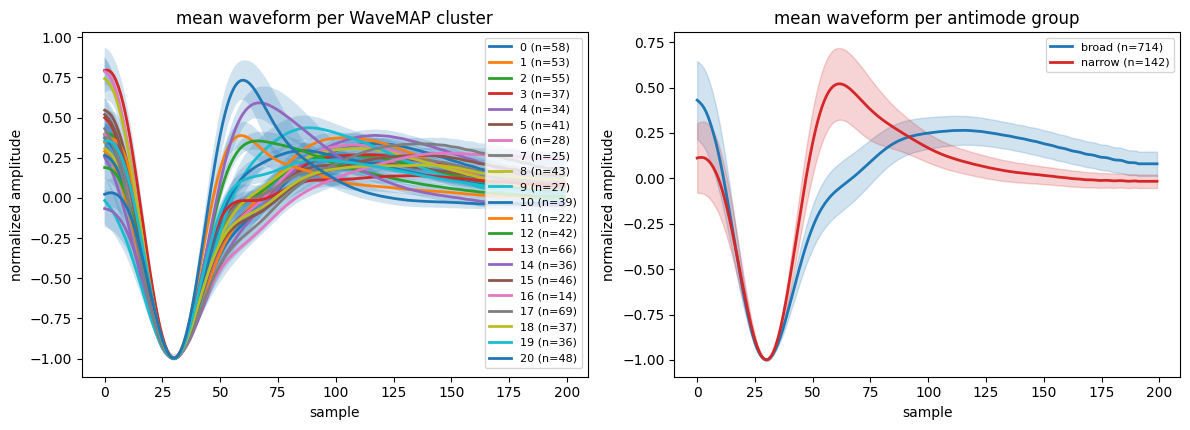

In [10]:
# [6.1] mean waveform per WaveMAP cluster and per antimode group
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
viz.plot_mean_waveforms(X, work.wavemap_cluster.to_numpy(), ax=axes[0])
axes[0].set_title('mean waveform per WaveMAP cluster')
viz.plot_mean_waveforms(X, work.wf_group.to_numpy(), palette=NB, ax=axes[1])
axes[1].set_title('mean waveform per antimode group')
fig.tight_layout(); plt.show()

## Section 7 — Save per-unit table + provenance

In [11]:
# [7.1] save the antimode label + WaveMAP cluster per unit, plus the recovery metrics
region_tag = '+'.join(a.lower() for a in SELECT_AREAS)
OUT_COLS = ['unit_id', 'subject', 'session_id', 'location', 'wf_group', 'wavemap_cluster',
            'wavemap_2class', 'trough_to_peak_ms', 'half_width_ms', 'mean_rate_hz',
            'umap_x', 'umap_y']
out_df = work[[c for c in OUT_COLS if c in work.columns]].copy()
out = PROJECT / 'outputs' / 'celltype' / f'unit_labels_wavemap_{region_tag}.csv'
out.parent.mkdir(parents=True, exist_ok=True)
out_df.to_csv(out, index=False)
prov = dict(dataset=DATASET, areas=SELECT_AREAS, n_units=int(len(out_df)),
            wf_split_ms=float(SPLIT_MS), pre_ms=PRE_MS, post_ms=POST_MS,
            n_neighbors=N_NEIGHBORS, resolution=RESOLUTION, seed=RS,
            n_clusters=int(len(sizes)), cluster_sizes=sizes,
            cluster_to_class={int(k): v for k, v in cl2class.items()},
            purity=purity, ari=float(ari), nmi=float(nmi))
out.with_suffix('.json').write_text(json.dumps(prov, indent=2))
print(f'wrote {out}  ({len(out_df)} units) + provenance {out.with_suffix(".json").name}')
out_df.head(12)

wrote e:\SBCAT\celltyping\outputs\celltype\unit_labels_wavemap_hippocampus+amygdala.csv  (856 units) + provenance unit_labels_wavemap_hippocampus+amygdala.json


,unit_id,subject,session_id,location,wf_group,wavemap_cluster,wavemap_2class,trough_to_peak_ms,half_width_ms,mean_rate_hz,umap_x,umap_y
0,sub-1_ses-1_ecephys+image_u022,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,0,broad,0.92,0.34,1.492994,-1.498588,2.610385
1,sub-1_ses-1_ecephys+image_u023,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,1,broad,0.81,0.34,0.384165,0.088896,0.716598
2,sub-1_ses-1_ecephys+image_u024,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,2,broad,0.87,0.31,5.972980,-0.009833,3.491666
3,sub-1_ses-1_ecephys+image_u025,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,2,broad,0.86,0.30,1.473657,0.361066,3.532446
4,sub-1_ses-1_ecephys+image_u026,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,3,broad,0.88,0.31,1.168133,-1.242699,3.434232
5,sub-1_ses-1_ecephys+image_u027,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,0,broad,0.89,0.32,0.979510,-1.608887,2.750618
6,sub-1_ses-1_ecephys+image_u028,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,4,broad,0.88,0.40,0.749653,-2.710311,0.734123
7,sub-1_ses-1_ecephys+image_u029,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,5,broad,0.90,0.30,2.164413,-0.448314,5.162439
8,sub-1_ses-1_ecephys+image_u030,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,6,broad,0.81,0.33,14.106782,0.391323,2.104624
9,sub-1_ses-1_ecephys+image_u031,sub-1,sub-1_ses-1_ecephys+image,amygdala_right,broad,6,broad,0.82,0.31,1.284925,-0.141413,2.342676


## Reading the result

- **`[4.1]`** is the visual: if the left panel (antimode colors) and right panel (WaveMAP clusters)
  carve the embedding the same way, WaveMAP recovered the width split unsupervised.
- **`[5.1]`** quantifies it: **purity** (collapse each cluster to its majority width-class — how
  accurate is that?) and **ARI/NMI**. Many WaveMAP clusters that each map cleanly to narrow *or*
  broad still counts as recovery — a coarse 2-way split can be over-resolved into pure sub-clusters.
- Low purity / mixed clusters (`[5.2]` verdict) means the full waveform shape carries structure the
  single trough-to-peak number misses — a real finding, not a bug.

Output `outputs/celltype/unit_labels_wavemap_<region>.csv` carries `wf_group`, the WaveMAP cluster,
and its collapsed `wavemap_2class` per `unit_id`; the `.json` sidecar stores the recovery metrics.